## Imports

In [1]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import shap
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns

## Load data from source

In [2]:


# fetch dataset
breast_cancer = fetch_ucirepo(id=14)

# data (as pandas dataframes)
X = breast_cancer.data.features
y = breast_cancer.data.targets

# metadata
print(breast_cancer.metadata)

# variable information
print(breast_cancer.variables)


{'uci_id': 14, 'name': 'Breast Cancer', 'repository_url': 'https://archive.ics.uci.edu/dataset/14/breast+cancer', 'data_url': 'https://archive.ics.uci.edu/static/public/14/data.csv', 'abstract': 'This breast cancer domain was obtained from the University Medical Centre, Institute of Oncology, Ljubljana, Yugoslavia. This is one of three domains provided by the Oncology Institute that has repeatedly appeared in the machine learning literature. (See also lymphography and primary-tumor.)', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 286, 'num_features': 9, 'feature_types': ['Categorical'], 'demographics': ['Age'], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Mar 07 2024', 'dataset_doi': '10.24432/C51P4M', 'creators': ['Matjaz Zwitter', 'Milan Soklic'], 'intro_paper': None, 'additional_info': {'summary': 'Thi

## EDA Section

In [3]:
display(X.describe())
display(y.describe())

,deg-malig
count,286.000000
mean,2.048951
std,0.738217
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


,Class
count,286
unique,2
top,no-recurrence-events
freq,201


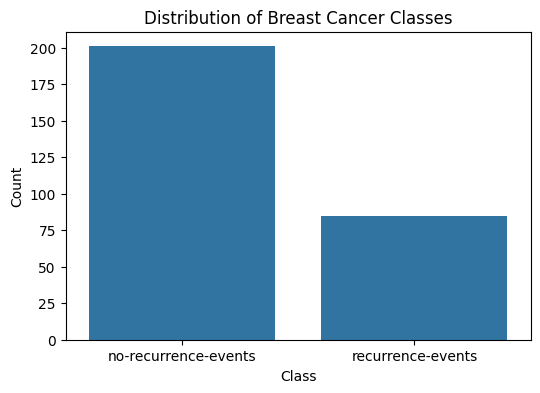

In [13]:
# plot the distribution of the target variable Class
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=y)
plt.title('Distribution of Breast Cancer Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [4]:
# missing values & data quality check
X.isnull().sum().sort_values(ascending=False)

,0
node-caps,8
breast-quad,1
age,0
tumor-size,0
menopause,0
inv-nodes,0
deg-malig,0
breast,0
irradiat,0


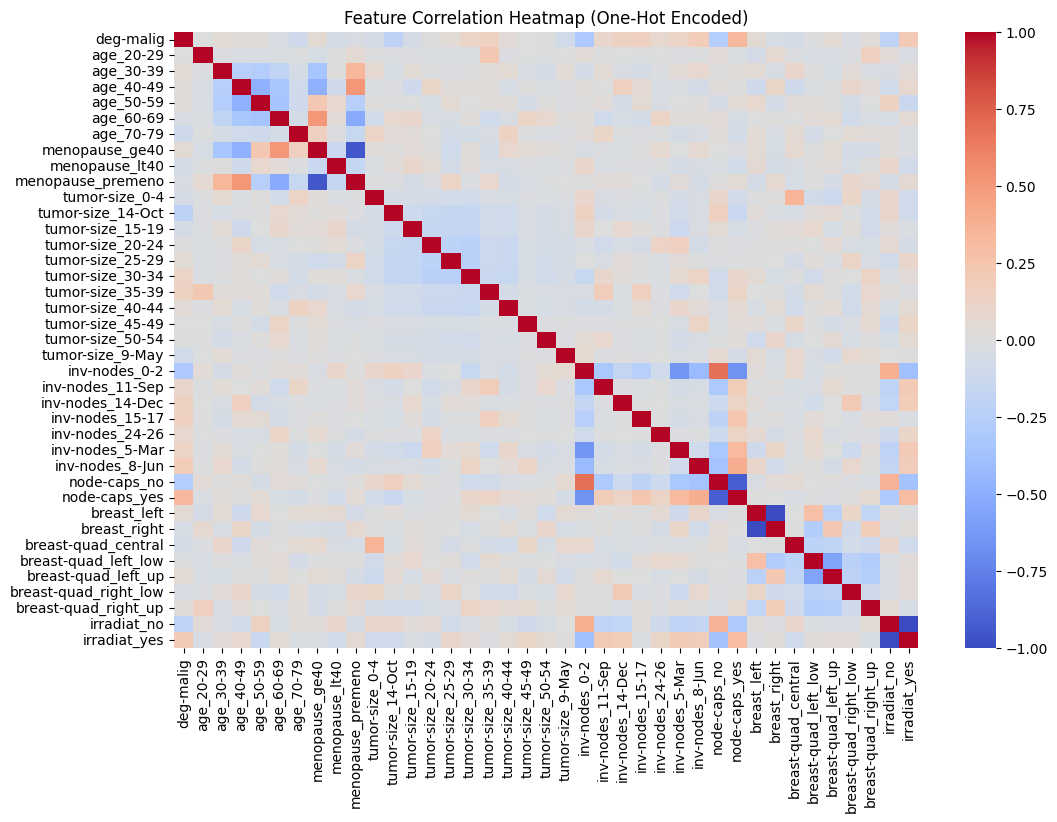

In [5]:
# feature correlation analysis
categorical_cols = X.select_dtypes(include='object').columns.tolist()
if 'deg-malig' in categorical_cols:
    categorical_cols.remove('deg-malig')

#  one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, dummy_na=False)

# correlation matrix on the encoded data
corr = X_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap (One-Hot Encoded)')
plt.show()

### Summary of findings

Based on the initial exploratory data analysis:

*   The dataset contains information about breast cancer patients with 9 features and a target variable 'Class' indicating recurrence events. Additionally there seems to be a large class imbalance bwtween recurrence events and non recurrence events.
*   Missing values are present in the 'node-caps' and 'breast-quad' features.
*   The correlation heatmap of the one-hot encoded features shows some relationships between variables, which could be further investigated. 'deg-malig' appears to have some correlation with several encoded features.

## Data Preprocessing

In [6]:
# replace '?' with NaN
X = X.replace('?', pd.NA)

# fill missing values with the mode of each feature
for col in X.columns:
    if X[col].isnull().any():
        mode_val = X[col].mode()[0]
        X[col] = X[col].fillna(mode_val)


print("missing values after filling:")
print(X.isnull().sum())

missing values after filling:
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
dtype: int64


In [7]:
# train test split:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#standardize feats:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train shape: (228, 39)
X_test shape: (58, 39)
y_train shape: (228, 1)
y_test shape: (58, 1)


## Methods and Models

In [8]:
#logistic regression model:

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("LR results")
print("accuracy:", accuracy_score(y_test, y_pred_lr))
print("confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("classification Report:\n", classification_report(y_test, y_pred_lr))


LR results
accuracy: 0.7068965517241379
confusion Matrix:
 [[35  6]
 [11  6]]
classification Report:
                       precision    recall  f1-score   support

no-recurrence-events       0.76      0.85      0.80        41
   recurrence-events       0.50      0.35      0.41        17

            accuracy                           0.71        58
           macro avg       0.63      0.60      0.61        58
        weighted avg       0.68      0.71      0.69        58



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
#random forrest model (ensemble model):
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n RF results")
print("accuracy:", accuracy_score(y_test, y_pred_rf))
print("confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("classification Report:\n", classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



 RF results
accuracy: 0.7241379310344828
confusion Matrix:
 [[36  5]
 [11  6]]
classification Report:
                       precision    recall  f1-score   support

no-recurrence-events       0.77      0.88      0.82        41
   recurrence-events       0.55      0.35      0.43        17

            accuracy                           0.72        58
           macro avg       0.66      0.62      0.62        58
        weighted avg       0.70      0.72      0.70        58



## Model overfitting?

No there does not seem ot be any evidence of model overfitting occuring  the test accuracy and cross-validation scores are reasonably close. If there was significant overfitting, you would typically see a much higher accuracy on the training data compared to the test data.

In [10]:

#  cross-validation strategy w 5 folds (we can change this as needed with repect to the dataset size)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


#  CV for Random Forest
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train.values.ravel(), cv=kf)

# CV for Logistic Regression
log_reg_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train.values.ravel(), cv=kf)

# eval cross-validation results for RF
print("random Forest CV scores:", rf_cv_scores)
print("mean CV Accuracy:", rf_cv_scores.mean())
print("SD of CV Accuracy:", rf_cv_scores.std())

# eval cross-validation results for LR
print("\nLR CV scores:", log_reg_cv_scores)
print("mean CV accuracy:", log_reg_cv_scores.mean())



random Forest CV scores: [0.67391304 0.67391304 0.7826087  0.73333333 0.75555556]
mean CV Accuracy: 0.7238647342995169
SD of CV Accuracy: 0.04366957372531258

LR CV scores: [0.69565217 0.56521739 0.7173913  0.55555556 0.68888889]
mean CV accuracy: 0.6445410628019325


## (gradstudent extra section) Get the feature importance of each model:

In [11]:

#RF first
feature_importances = rf.feature_importances_
feature_names = X_train.columns
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
print(feature_importances_df)

                  Feature  Importance
0               deg-malig    0.119710
21          inv-nodes_0-2    0.048657
34    breast-quad_left_up    0.042358
28           node-caps_no    0.041841
14       tumor-size_25-29    0.041684
33   breast-quad_left_low    0.040083
36   breast-quad_right_up    0.038344
29          node-caps_yes    0.036629
4               age_50-59    0.036020
31           breast_right    0.035784
15       tumor-size_30-34    0.034895
7          menopause_ge40    0.034357
3               age_40-49    0.033027
9       menopause_premeno    0.032843
13       tumor-size_20-24    0.032562
30            breast_left    0.031310
38           irradiat_yes    0.031246
37            irradiat_no    0.028670
5               age_60-69    0.028312
26        inv-nodes_5-Mar    0.025686
17       tumor-size_40-44    0.023366
16       tumor-size_35-39    0.021323
22       inv-nodes_11-Sep    0.020935
11      tumor-size_14-Oct    0.019962
2               age_30-39    0.019638
12       tum

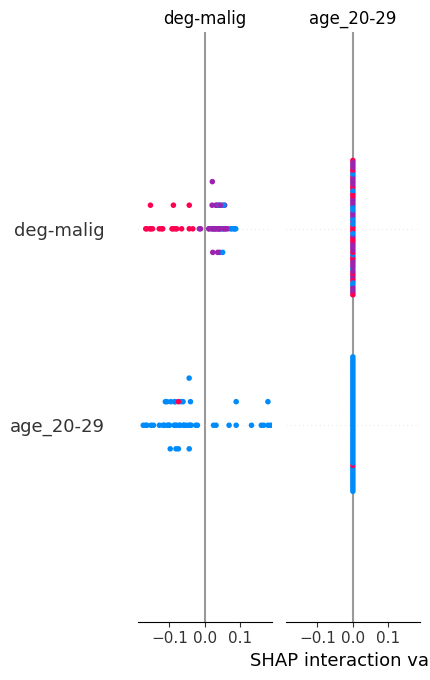

In [12]:
#SHAP vals for LR model

shap_values = shap.TreeExplainer(rf).shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## key features from SHAP and feature importance

`deg-malig` is the top feature among the SHAP analysis and the random forest feature importance moddule this feature  represents the degree of malignancy fo feature importance it has a vlaue of   0.119710 and for SHAP that same feature has a vlaue of -0.1 to 0.1 (roughly)

## Key features from SHAP and feature importance

Based on both the Random Forest feature importance and SHAP analysis for the Random Forest model, `deg-malig` is identified as a consistent key feature. This feature represents the degree of malignancy. For Random Forest feature importance, it has a value of  0.1197, and for the SHAP analysis of the Random Forest model, this feature's values generally range from around -0.1 to 0.1, indicating its significant influence on the model's output. The consistency of `deg-malig` across both analysis methods further shows its importance in the model's predictions.

## Conclusion

* include a summary of objectives, model performance results, key findings, and limitations. Offer recommendations for future work and highlight the real-world impact or applications of yourmodel. Conclude with a brief, impactful statement about the project’s significance.

The primary objectives of this project were to explore the dataset, identify meaningful patterns, and evaluate model performance.

Both machine learning models achieved moderate performance, with accuracy scores around 70% verified through K-fold cross-validation. A key limitation contributing to this result was the relatively small dataset with only a few hundred records Machine learning models generally require large amounts of data to learn deep and meaningful patterns, and the limited sample size restricted the models’ ability to generalize effectively. Future work should focus on expanding the dataset, performing hyperparameter optimization, and potentially exploring more advanced architectures such as ensemble or deep learning methods.

Machine learning continues to have a transformative impact in healthcare. It is already improving diagnostic accuracy in medical imaging, identifying high-risk patients based on clinical history, and predicting patient responses to medications. These capabilities have the potential to enhance patient outcomes, reduce medical costs, and support data-driven clinical decision-making.

In conclusion, while this study demonstrates promising results, it also highlights the challenges of working with limited data in a complex domain like healthcare. With further refinement and access to larger datasets machine learning models can become powerful tools for delivering personalized and accurate medical predictions. This project reinforces the potential impact of machine learning not just as a technical achievement but as a step toward improving real-world healthcare outcomes.

## References

[1] Scikit-learn developers. (n.d.). sklearn.preprocessing.OneHotEncoder. scikit-learn. Retrieved from https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

[2] Scikit-learn developers. (n.d.). sklearn.metrics. scikit-learn. Retrieved from https://scikit-learn.org/stable/api/sklearn.metrics.html

[3] GeeksforGeeks. (2023, December 8). Data Analysis | Exploring Correlation in Python. Retrieved from https://www.geeksforgeeks.org/data-analysis/exploring-correlation-in-python/

## References

[1] sklearn.preprocessing.OneHotEncoder. scikit-learn. Retrieved from https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

[2] sklearn.metrics. scikit-learn. Retrieved from https://scikit-learn.org/stable/api/sklearn.metrics.html

[3] Data Analysis | Exploring Correlation in Python. GeeksforGeeks. (2023, December 8). Retrieved from https://www.geeksforgeeks.org/data-analysis/exploring-correlation-in-python/